# Analyzing the results of counterfactual explanations on MNIST


In [52]:
# import relevant packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # use deep

In [53]:
# import results
results = pd.read_csv('results/mnist_full_results.csv', index_col=0)
# fix mistake in creating the csv
results.drop('weak correctness', axis=1, inplace=True)
results.head(10)

,network,image,original_label,original_predicted_label,predicted_label,target,method,IM1,IM2,correctness,l1,l2,linf,implausibility,optim_time,weak_correctness
0,mnist_output_100,0.0,7,7,NaN,0.0,alibi-CF,NaN,NaN,0,NaN,NaN,NaN,NaN,4.768510,0
1,mnist_output_100,0.0,7,7,NaN,1.0,alibi-CF,NaN,NaN,0,NaN,NaN,NaN,NaN,4.600064,0
2,mnist_output_100,0.0,7,7,NaN,2.0,alibi-CF,NaN,NaN,0,NaN,NaN,NaN,NaN,3.915866,0
3,mnist_output_100,0.0,7,7,NaN,3.0,alibi-CF,NaN,NaN,0,NaN,NaN,NaN,NaN,3.973385,0
4,mnist_output_100,0.0,7,7,NaN,4.0,alibi-CF,NaN,NaN,0,NaN,NaN,NaN,NaN,3.924591,0
5,mnist_output_100,0.0,7,7,NaN,5.0,alibi-CF,NaN,NaN,0,NaN,NaN,NaN,NaN,4.046250,0
6,mnist_output_100,0.0,7,7,NaN,6.0,alibi-CF,NaN,NaN,0,NaN,NaN,NaN,NaN,4.278754,0
7,mnist_output_100,0.0,7,7,NaN,8.0,alibi-CF,NaN,NaN,0,NaN,NaN,NaN,NaN,4.862746,0
8,mnist_output_100,0.0,7,7,NaN,9.0,alibi-CF,NaN,NaN,0,NaN,NaN,NaN,NaN,4.208386,0
9,mnist_output_100,1.0,2,2,NaN,0.0,alibi-CF,NaN,NaN,0,NaN,NaN,NaN,NaN,4.192075,0


In [54]:
results[results['method'] == 'alibi-Proto-CF'][results['network'] == 'mnist_cnn_output_100'][results['predicted_label'].notna()]

C:\Users\enriq\AppData\Local\Temp\ipykernel_10572\1420616722.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  results[results['method'] == 'alibi-Proto-CF'][results['network'] == 'mnist_cnn_output_100'][results['predicted_label'].notna()]
C:\Users\enriq\AppData\Local\Temp\ipykernel_10572\1420616722.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  results[results['method'] == 'alibi-Proto-CF'][results['network'] == 'mnist_cnn_output_100'][results['predicted_label'].notna()]


,network,image,original_label,original_predicted_label,predicted_label,target,method,IM1,IM2,correctness,l1,l2,linf,implausibility,optim_time,weak_correctness
5449,mnist_cnn_output_100,0.0,7,7,4.0,4.0,alibi-Proto-CF,1.700308,0.264895,1,382.21353,14.611949,1.806576,401.28604,50.995885,1
5457,mnist_cnn_output_100,1.0,2,2,4.0,4.0,alibi-Proto-CF,1.631145,0.204935,1,607.31964,23.140940,2.000000,658.09610,52.535036,1
5460,mnist_cnn_output_100,1.0,2,2,7.0,7.0,alibi-Proto-CF,1.130343,0.239166,1,192.72757,7.654458,0.827351,494.01685,53.014567,1
5461,mnist_cnn_output_100,1.0,2,2,8.0,8.0,alibi-Proto-CF,1.038547,0.159498,1,686.72820,29.700825,2.000000,991.91644,55.708626,1
5466,mnist_cnn_output_100,2.0,1,1,4.0,4.0,alibi-Proto-CF,0.494779,0.235471,1,627.41284,23.225380,1.723115,612.82697,54.207111,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6322,mnist_cnn_output_100,97.0,7,7,4.0,4.0,alibi-Proto-CF,1.717184,0.185293,1,577.08020,23.337101,2.000000,764.38495,317.422611,1
6325,mnist_cnn_output_100,97.0,7,7,8.0,8.0,alibi-Proto-CF,1.125826,0.212410,1,808.12580,37.834133,2.000000,1483.72020,318.434300,1
6331,mnist_cnn_output_100,98.0,6,6,4.0,4.0,alibi-Proto-CF,1.118024,0.212838,1,596.01935,22.600363,1.927250,635.56805,321.087958,1
6333,mnist_cnn_output_100,98.0,6,6,7.0,7.0,alibi-Proto-CF,0.812112,0.328084,1,249.07861,10.043620,1.808143,378.31656,319.925344,1


In [55]:
# fix correctness and weak correctness for captum
results.loc[results['method'] == 'Captum-MinParamPerturbation', 'correctness'] = (
    results.loc[results['method'] == 'Captum-MinParamPerturbation']
    .apply(lambda row: 1 if pd.notna(row['predicted_label']) and row['original_predicted_label'] != row['predicted_label'] else 0, axis=1)
)

In [56]:
results['weak_correctness'] = results.groupby(['network', 'method', 'image'])['correctness'].transform('max')

## Question 1: How many instances are correct or weakly correct? 

- Are some methods more correct than others? 
- Does this change per network?
- Are certain decision changes more correct than others?
- Is correctness correlated with something?

In [57]:
sum_correctness = results.groupby('method')['correctness'].sum()
count_correctness = results.groupby('method')['correctness'].count()
percentage_correctness = (sum_correctness / count_correctness) * 100

# Display percentage of correct instances (including failed attempts NaNs)
print(percentage_correctness)

method
C-Min-Edit                     68.649458
Captum-MinParamPerturbation    64.309764
Min-Edit                       61.690984
PIECE                          27.216611
alibi-CF                       60.549944
alibi-Proto-CF                 67.209128
Name: correctness, dtype: float64


In [58]:
sum_correctness = results.groupby('method')['weak_correctness'].sum()
count_correctness = results.groupby('method')['weak_correctness'].count()
percentage_correctness = (sum_correctness / count_correctness) * 100

# Display percentage of correct instances (including failed attempts NaNs)
print(percentage_correctness)

method
C-Min-Edit                      98.821549
Captum-MinParamPerturbation     64.309764
Min-Edit                        97.643098
PIECE                           78.787879
alibi-CF                        76.599327
alibi-Proto-CF                 100.000000
Name: weak_correctness, dtype: float64


In [59]:
filtered_results = results[results['predicted_label'].notna()]

In [60]:
sum_correctness = filtered_results.groupby('method')['correctness'].sum()
count_correctness = filtered_results.groupby('method')['correctness'].count()

# Calculate the percentage of correctness
percentage_correctness = (sum_correctness / count_correctness) * 100

# Display percentage
print(percentage_correctness)

method
C-Min-Edit                      68.649458
Captum-MinParamPerturbation     64.418212
Min-Edit                        61.690984
PIECE                           27.216611
alibi-CF                        99.722736
alibi-Proto-CF                 100.000000
Name: correctness, dtype: float64


In [61]:
sum_correctness = filtered_results.groupby('method')['weak_correctness'].sum()
count_correctness = filtered_results.groupby('method')['weak_correctness'].count()

# Calculate the percentage of correctness
percentage_correctness = (sum_correctness / count_correctness) * 100

# Display percentage
print(percentage_correctness)

method
C-Min-Edit                      98.821549
Captum-MinParamPerturbation     64.418212
Min-Edit                        97.643098
PIECE                           78.787879
alibi-CF                        99.722736
alibi-Proto-CF                 100.000000
Name: weak_correctness, dtype: float64


So what does this tell us? Overall the alibi methods almost always produce valid explanations if they produce anything at all (no explanation produced). It would be interesting to find out how this changes over the different network architectures next. Since Captum's counterfactual explanation implementation is not targeted and only produces 1 explanation per instance, weak correctness is the same thing as correctness. This also (almost) doesn't change when we remove NaN values (no explanation is produced). This means that Captum is right 64\% of the time. The C-Min-Edit and Min-Edit approaches improve significantly when we account for weak correctness, meaning at least one explanation for that instance is correct. This might be due to some decision boundaries being further apart. Lastly PIECE also improves significantly if we use weak correctness (from 27 to 78\%). 

In [128]:
# Let's investigate the same question but also group by network
sum_correctness = results.groupby(['method', 'network'])['correctness'].sum()
count_correctness = results.groupby(['method', 'network'])['correctness'].count()
percentage_correctness = (sum_correctness / count_correctness) * 100

# Display percentage of correct instances (including failed attempts NaNs)
print(percentage_correctness)

df_correctness = percentage_correctness.reset_index()

method                       network               
C-Min-Edit                   mnist_alibi_cnn_output     59.147026
                             mnist_cnn_output_100       74.410774
                             mnist_lenet5_output        40.291807
                             mnist_output_100           86.756453
                             mnist_resnet8_output       64.309764
                             mnist_schut_mlp_output     86.980920
Captum-MinParamPerturbation  mnist_alibi_cnn_output     26.262626
                             mnist_cnn_output_100        0.000000
                             mnist_lenet5_output        64.646465
                             mnist_output_100           97.979798
                             mnist_resnet8_output      100.000000
                             mnist_schut_mlp_output     96.969697
Min-Edit                     mnist_alibi_cnn_output     58.585859
                             mnist_cnn_output_100       66.105499
                        

In [129]:
sum_correctness = results.groupby(['method', 'network'])['weak_correctness'].sum()
count_correctness = results.groupby(['method', 'network'])['weak_correctness'].count()
percentage_correctness = (sum_correctness / count_correctness) * 100

# Display percentage of correct instances (including failed attempts NaNs)
print(percentage_correctness)
df_weakcorrectness = percentage_correctness.reset_index()
df_weakcorrectness.rename({'weak_correctness': 'correctness'}, axis=1, inplace=True)

method                       network               
C-Min-Edit                   mnist_alibi_cnn_output     95.959596
                             mnist_cnn_output_100      100.000000
                             mnist_lenet5_output        98.989899
                             mnist_output_100           98.989899
                             mnist_resnet8_output       98.989899
                             mnist_schut_mlp_output    100.000000
Captum-MinParamPerturbation  mnist_alibi_cnn_output     26.262626
                             mnist_cnn_output_100        0.000000
                             mnist_lenet5_output        64.646465
                             mnist_output_100           97.979798
                             mnist_resnet8_output      100.000000
                             mnist_schut_mlp_output     96.969697
Min-Edit                     mnist_alibi_cnn_output     96.969697
                             mnist_cnn_output_100      100.000000
                        

In [130]:
sum_correctness = filtered_results.groupby(['method', 'network'])['correctness'].sum()
count_correctness = filtered_results.groupby(['method', 'network'])['correctness'].count()
percentage_correctness = (sum_correctness / count_correctness) * 100

# Display percentage of correct instances 
print(percentage_correctness)
df_filtered_correctness = percentage_correctness.reset_index()

method                       network               
C-Min-Edit                   mnist_alibi_cnn_output     59.147026
                             mnist_cnn_output_100       74.410774
                             mnist_lenet5_output        40.291807
                             mnist_output_100           86.756453
                             mnist_resnet8_output       64.309764
                             mnist_schut_mlp_output     86.980920
Captum-MinParamPerturbation  mnist_alibi_cnn_output     26.262626
                             mnist_cnn_output_100        0.000000
                             mnist_lenet5_output        65.306122
                             mnist_output_100           97.979798
                             mnist_resnet8_output      100.000000
                             mnist_schut_mlp_output     96.969697
Min-Edit                     mnist_alibi_cnn_output     58.585859
                             mnist_cnn_output_100       66.105499
                        

In [131]:
sum_correctness = filtered_results.groupby(['method', 'network'])['weak_correctness'].sum()
count_correctness = filtered_results.groupby(['method', 'network'])['weak_correctness'].count()
percentage_correctness = (sum_correctness / count_correctness) * 100

# Display percentage of correct instances 
print(percentage_correctness)
df_filtered_weakcorrectness = percentage_correctness.reset_index()
df_filtered_weakcorrectness.rename({'weak_correctness': 'correctness'}, axis=1, inplace=True)

method                       network               
C-Min-Edit                   mnist_alibi_cnn_output     95.959596
                             mnist_cnn_output_100      100.000000
                             mnist_lenet5_output        98.989899
                             mnist_output_100           98.989899
                             mnist_resnet8_output       98.989899
                             mnist_schut_mlp_output    100.000000
Captum-MinParamPerturbation  mnist_alibi_cnn_output     26.262626
                             mnist_cnn_output_100        0.000000
                             mnist_lenet5_output        65.306122
                             mnist_output_100           97.979798
                             mnist_resnet8_output      100.000000
                             mnist_schut_mlp_output     96.969697
Min-Edit                     mnist_alibi_cnn_output     96.969697
                             mnist_cnn_output_100      100.000000
                        

In [132]:
df_correctness['Source'] = 'correctness, unfiltered'
df_weakcorrectness['Source'] = 'weak correctness, unfiltered'
df_filtered_correctness['Source'] = 'correctness, filtered'
df_filtered_weakcorrectness['Source'] = 'weak correctness, filtered'

# Combine the DataFrames
df = pd.concat([df_correctness, df_weakcorrectness, df_filtered_correctness, df_filtered_weakcorrectness], ignore_index=True)
df

,method,network,correctness,Source
0,C-Min-Edit,mnist_alibi_cnn_output,59.147026,"correctness, unfiltered"
1,C-Min-Edit,mnist_cnn_output_100,74.410774,"correctness, unfiltered"
2,C-Min-Edit,mnist_lenet5_output,40.291807,"correctness, unfiltered"
3,C-Min-Edit,mnist_output_100,86.756453,"correctness, unfiltered"
4,C-Min-Edit,mnist_resnet8_output,64.309764,"correctness, unfiltered"
...,...,...,...,...
139,alibi-Proto-CF,mnist_cnn_output_100,100.000000,"weak correctness, filtered"
140,alibi-Proto-CF,mnist_lenet5_output,100.000000,"weak correctness, filtered"
141,alibi-Proto-CF,mnist_output_100,100.000000,"weak correctness, filtered"
142,alibi-Proto-CF,mnist_resnet8_output,100.000000,"weak correctness, filtered"


In [133]:
df['method'] = df.method.replace(to_replace='Captum-MinParamPerturbation', value='Captum')

In [134]:
df

,method,network,correctness,Source
0,C-Min-Edit,mnist_alibi_cnn_output,59.147026,"correctness, unfiltered"
1,C-Min-Edit,mnist_cnn_output_100,74.410774,"correctness, unfiltered"
2,C-Min-Edit,mnist_lenet5_output,40.291807,"correctness, unfiltered"
3,C-Min-Edit,mnist_output_100,86.756453,"correctness, unfiltered"
4,C-Min-Edit,mnist_resnet8_output,64.309764,"correctness, unfiltered"
...,...,...,...,...
139,alibi-Proto-CF,mnist_cnn_output_100,100.000000,"weak correctness, filtered"
140,alibi-Proto-CF,mnist_lenet5_output,100.000000,"weak correctness, filtered"
141,alibi-Proto-CF,mnist_output_100,100.000000,"weak correctness, filtered"
142,alibi-Proto-CF,mnist_resnet8_output,100.000000,"weak correctness, filtered"


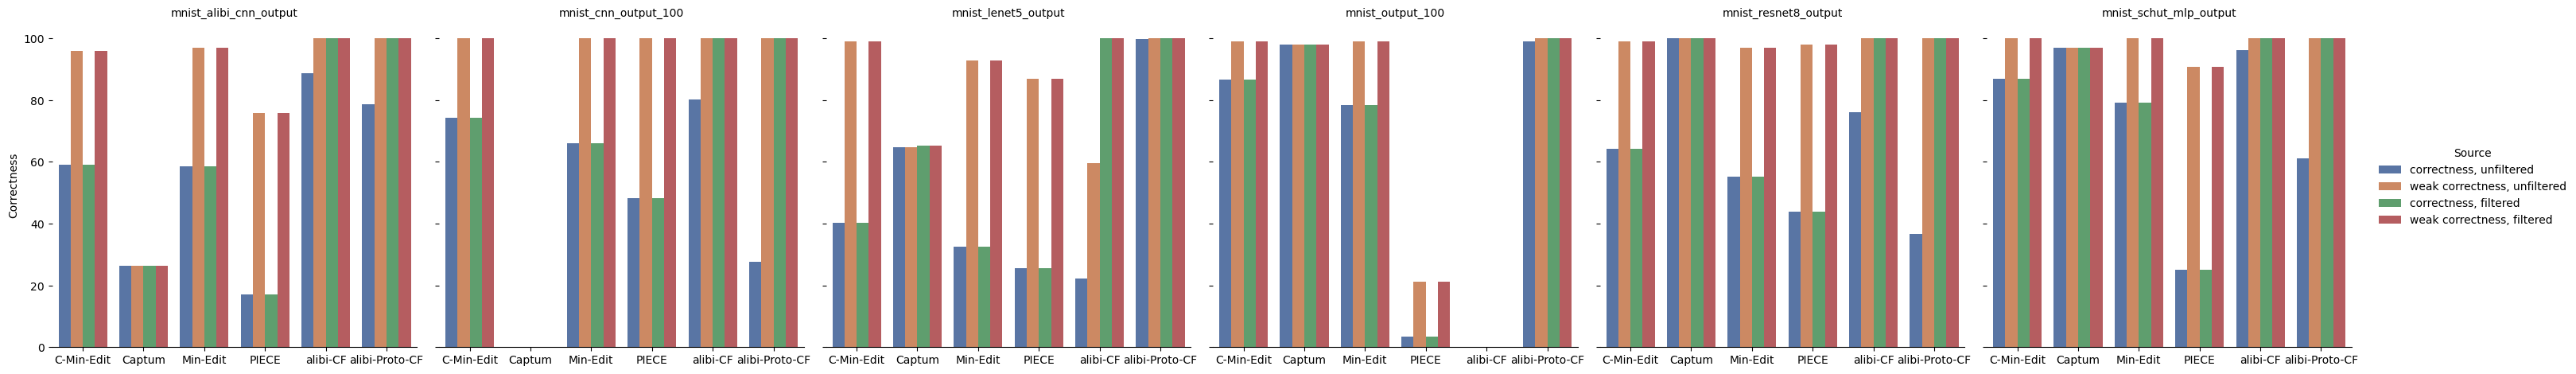

In [136]:
g = sns.catplot(
    data=df, x="method", y="correctness", hue="Source", col="network",
    kind="bar", height=5, aspect=1, palette="deep"
)
g.set_axis_labels("", "Correctness")

g.set_titles("{col_name}")
g.despine(left=True)

So what trends do we see per network? For the network named mnist_cnn_output_100, which is the cnn taken from the PIECE paper, we see that Captum cannot find any explanations, whilst if we use weak correctness as a measure, all other methods are 100\% correct. This changes drastically when we are stricter with our definition of correctness. For example, PIECE jumps from less than 50\% correctly explained instances to 100 if you count that at least 1 explanation correct per instance is enough. This implies that these methods only perform well if the decision boundary is 'easy'. Further investigation is needed to confirm this implication. Looking at the network named mnist_output_100, which is a simple mlp and the only network that was not trained by us (the network was sourced from a neural network verification benchmark and the resulting keras and torch weights came from a translated ONNX file). Considering this network is an 'outlier' in this sense, this could be a reason why there is really poor performance using PIECE and alibi-CF (alibi-CF has 0 correct explanations). Another interesting thing to note here is that whilst alibi-CF performs badly here, alibi-Proto-CF performs almost perfectly. This is almost reversed when comparing to mnist_cnn_output_100, where alibi-Proto-CF has very low correctness (it does have high correctness on the explanations it does find). Looking for trends among the other networks, alibi-CF performs better than alibi-Proto-CF on all networks except mnist_cnn_output_100 and mnist_lenet5_output (LeNet5 architecture). 

In [ ]:
# Add heatmaps next to uncover correctness for each decision boundary

